### Modeling Approach

This notebook evaluates multiple regression models to predict residential home sale prices.

The target variable is the log-transformed sale price (`log_sale_price`).

Using a log transformation helps:

- reduce right-skew in price distributions
- stabilize variance
- improve regression model performance

Model performance is evaluated using:

• Mean Absolute Error (MAE)  
• R² score  
• Cross-validation performance

Since the model predicts log(price), predictions are exponentiated before calculating MAE to express errors in dollar terms.

##### Import libraries and data

In [1]:
# Core analysis libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Improve plot styling
sns.set()

# Show all columns
pd.set_option('display.max_columns', None)

In [2]:
# File path locations
from pathlib import Path

# File paths
PROJECT_ROOT = Path.cwd().resolve().parent
CLEAN_DATA_DIR = PROJECT_ROOT / "data/clean_data"
RAW_DATA_DIR = PROJECT_ROOT / "data/raw_data"
MODELS_DIR = PROJECT_ROOT / "models"
SRC_DIR = PROJECT_ROOT / "src"
DEPLOYMENT_DIR = PROJECT_ROOT / "deployment"

In [3]:
data = pd.read_parquet(CLEAN_DATA_DIR / "03_feature_engineering.parquet")
data.head()

,log_gross_sqft,build_age_yrs,log_dist_to_station,neighborhood_bath_beach,neighborhood_bay_ridge,neighborhood_bedford_stuyvesant,neighborhood_bensonhurst,neighborhood_bergen_beach,neighborhood_boerum_hill,neighborhood_borough_park,neighborhood_brighton_beach,neighborhood_brooklyn_heights,neighborhood_brownsville,neighborhood_bushwick,neighborhood_canarsie,neighborhood_carroll_gardens,neighborhood_clinton_hill,neighborhood_cobble_hill,neighborhood_cobble_hill_west,neighborhood_coney_island,neighborhood_crown_heights,neighborhood_cypress_hills,neighborhood_dyker_heights,neighborhood_east_new_york,neighborhood_flatbush_central,neighborhood_flatbush_east,neighborhood_flatbush_lefferts_garden,neighborhood_flatbush_north,neighborhood_flatlands,neighborhood_fort_greene,neighborhood_gerritsen_beach,neighborhood_gowanus,neighborhood_gravesend,neighborhood_greenpoint,neighborhood_kensington,neighborhood_madison,neighborhood_manhattan_beach,neighborhood_marine_park,neighborhood_midwood,neighborhood_mill_basin,neighborhood_ocean_hill,neighborhood_ocean_parkway_north,neighborhood_ocean_parkway_south,neighborhood_old_mill_basin,neighborhood_park_slope,neighborhood_park_slope_south,neighborhood_prospect_heights,neighborhood_red_hook,neighborhood_seagate,neighborhood_sheepshead_bay,neighborhood_sunset_park,neighborhood_williamsburg_central,neighborhood_williamsburg_east,neighborhood_williamsburg_north,neighborhood_williamsburg_south,neighborhood_windsor_terrace,neighborhood_wyckoff_heights,building_class_category_one_family_dwellings,building_class_category_rentals_elevator_apartments,building_class_category_rentals_walkup_apartments,building_class_category_three_family_dwellings,building_class_category_two_family_dwellings,within_half_mi,log_sale_price
0,-1.678863,-0.474436,-0.098884,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,5.934498
1,-0.305581,-0.037818,-0.913277,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,6.071882
2,-0.093172,0.071337,0.072074,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,6.113943
3,0.180062,0.180491,0.589510,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.954243
4,-0.875544,0.398800,0.492291,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,5.968483


In [4]:
data.shape

(5596, 64)

In [5]:
# Define target
y = data["log_sale_price"]

In [6]:
# Define features
X = data.drop("log_sale_price", axis=1)

### Train-Test Split

The dataset is divided into training and testing sets.

The training set is used to fit model parameters, while the testing set provides an unbiased evaluation of model performance.

This ensures that reported metrics reflect the model's ability to generalize to unseen data.

In [7]:
# Perform train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=10
)

### Ordinary Least Squares (Baseline Model)

We begin with a standard linear regression model as a baseline.

Linear regression assumes:

• a linear relationship between predictors and the target  
• independence between predictors  
• constant variance of residuals

Performance metrics:

- Train Adjusted R²: **0.599**
- Test R²: **0.541**
- Test MAE: **$474,825.12**

The baseline model provides a benchmark against which more flexible models can be compared.

##### OLS Regression -- Scikit-learn

In [8]:
# For Method config attributes always show
from sklearn import set_config
set_config(print_changed_only=False, display="diagram")

In [9]:
# Linear regression
from sklearn.linear_model import LinearRegression
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, positive=False)

##### OLS Regression -- Statsmodels

In [10]:
import statsmodels.api as sm

In [11]:
# Add constants to X
X_train_sm = sm.add_constant(X_train).astype(float)
X_test_sm = sm.add_constant(X_test).astype(float)

In [12]:
sm_model = sm.OLS(y_train, X_train_sm).fit()
sm_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         log_sale_price   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.600
Method:                 Least Squares   F-statistic:                     110.9
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:10:14   Log-Likelihood:                 1242.5
No. Observations:                4476   AIC:                            -2361.
Df Residuals:                    4414   BIC:                            -1964.
Df Model:                          61                                         
Covariance Type:            nonrobust                                         
=======================================================================================================================
                                                          coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
const                                                   5.0576      0.011    459.621      0.000       5.036       5.079
log_gross_sqft                                          0.1157      0.004     26.952      0.000       0.107       0.124
build_age_yrs                                          -0.0078      0.005     -1.431      0.153      -0.019       0.003
log_dist_to_station                                     0.0091      0.005      1.793      0.073      -0.001       0.019
neighborhood_bath_beach                                 0.0578      0.023      2.462      0.014       0.012       0.104
neighborhood_bay_ridge                                  0.0346      0.015      2.307      0.021       0.005       0.064
neighborhood_bedford_stuyvesant                         0.1224      0.012     10.492      0.000       0.100       0.145
neighborhood_bensonhurst                                0.0586      0.015      3.898      0.000       0.029       0.088
neighborhood_bergen_beach                              -0.1319      0.027     -4.966      0.000      -0.184      -0.080
neighborhood_boerum_hill                                0.4192      0.032     12.963      0.000       0.356       0.483
neighborhood_borough_park                               0.1191      0.013      9.016      0.000       0.093       0.145
neighborhood_brighton_beach                            -0.1089      0.034     -3.186      0.001      -0.176      -0.042
neighborhood_brooklyn_heights                           0.6550      0.042     15.742      0.000       0.573       0.737
neighborhood_brownsville                               -0.2211      0.023     -9.552      0.000      -0.266      -0.176
neighborhood_bushwick                                   0.0479      0.015      3.147      0.002       0.018       0.078
neighborhood_canarsie                                  -0.1766      0.014    -12.680      0.000      -0.204      -0.149
neighborhood_carroll_gardens                            0.3446      0.030     11.462      0.000       0.286       0.404
neighborhood_clinton_hill                               0.3426      0.028     12.113      0.000       0.287       0.398
neighborhood_cobble_hill                                0.5334      0.033     16.097      0.000       0.468       0.598
neighborhood_cobble_hill_west                           0.3525      0.058      6.121      0.000       0.240       0.465
neighborhood_coney_island                              -0.2667      0.044     -6.085      0.000      -0.353      -0.181
neighborhood_crown_heights                              0.0657      0.017      3.952      0.000       0.033       0.098
neighborhood_cypress_hills                             -0.1618      0.021     -7.81

In [13]:
# Create coefficients table
pvalues = sm_model.pvalues
coeffs = sm_model.params

sm_summary = pd.DataFrame({
    "Feature" : pvalues.index, 
    "Coefficient" : coeffs.values, 
    "p-value" : pvalues.values.round(3)
}).sort_values("p-value", ascending=False)

key_features = ["log_gross_sqft", "log_dist_to_station", "within_half_mi", "build_age_yrs"]

sm_summary["Percent Effect"] = ((10 ** sm_summary["Coefficient"] - 1) * 100).round(2)
sm_summary[sm_summary["Feature"].isin(key_features)]

,Feature,Coefficient,p-value,Percent Effect
2,build_age_yrs,-0.007827,0.153,-1.79
3,log_dist_to_station,0.009118,0.073,2.12
1,log_gross_sqft,0.115652,0.000,30.51
63,within_half_mi,0.041947,0.000,10.14


##### OLS predictions & assessments

In [14]:
y_pred_log = ols_model.predict(X_test)

y_pred = 10 ** y_pred_log
y_test_actual = 10 ** y_test

In [15]:
# MAE and RMSE

from sklearn.metrics import mean_absolute_error, mean_squared_error

ols_mae = mean_absolute_error(y_test_actual, y_pred)
ols_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

print("Test MAE ($):", round(ols_mae, 2))
print("Test RMSE ($):", round(ols_rmse, 2))

Test MAE ($): 474825.12
Test RMSE ($): 908444.85


In [16]:
# Median sales price
med_sale_price = (10 ** np.median(data["log_sale_price"])).round(2)
print("Median Brooklyn sales price ($):", med_sale_price)

Median Brooklyn sales price ($): 1216998.36


In [17]:
# Relative error
relative_error = (ols_mae / med_sale_price).round(2)
print("OLS relative error (%):", relative_error)

OLS relative error (%): 0.39


##### Model Baseline Metrics

In [18]:
# Train R-squared
ols_train_r2 = round(ols_model.score(X_train, y_train), 3)
print("Train R-squared:", ols_train_r2)

Train R-squared: 0.605


In [19]:
# Test R-squared
ols_test_r2 = round(ols_model.score(X_test, y_test), 3)
print("Test R-squared:", ols_test_r2)

Test R-squared: 0.567


In [20]:
# Adjusted R-Squared function
def adjusted_r2(r2, n, p):
    result = 1 - (1 - r2) * (n - 1)/(n - p - 1)
    return round(result, 3)

In [21]:
# Train adjusted R-squared
ols_train_adj_r2 = adjusted_r2(ols_train_r2, X_train.shape[0], X_train.shape[1])
print("Train Adjusted R-squared:", ols_train_adj_r2)

Train Adjusted R-squared: 0.599


In [22]:
# Test adjusted R-squared
ols_test_adj_r2 = adjusted_r2(ols_test_r2, X_test.shape[0], X_test.shape[1])
print("Test Adjusted R-squared:", ols_test_adj_r2)

Test Adjusted R-squared: 0.541


### Elastic Net Regression

Elastic Net combines L1 (Lasso) and L2 (Ridge) regularization.

This helps:

• reduce overfitting  
• manage multicollinearity  
• perform implicit feature selection

Cross-validation was used to select optimal regularization parameters.

Performance metrics:

- Train Adjusted R²: **0.562**
- Test R²: **0.562**
- Test MAE: **$474,111.60**

Elastic Net often performs well when predictors are correlated.

In [23]:
# Scaling for Elastic Net
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
# Import library
from sklearn.linear_model import ElasticNetCV

In [25]:
# Elastic Net
elastic_model = ElasticNetCV(
    cv=5,
    l1_ratio=[0.1, 0.5, 0.9],
    max_iter=10000,
    verbose=0
)

elastic_model.fit(X_train_scaled, y_train)

ElasticNetCV(alphas=None, copy_X=True, cv=5, eps=0.001, fit_intercept=True,
             l1_ratio=[0.1, 0.5, 0.9], max_iter=10000, n_alphas=100,
             n_jobs=None, positive=False, precompute='auto', random_state=None,
             selection='cyclic', tol=0.0001, verbose=0)

In [26]:
# Best values for alpha (learning rate) and L1 Ratio (balance between Lasso and Ridge regression)
print("Regularization strength", (elastic_model.alpha_).round(6))
print("Lasso/Ridge balance is", elastic_model.l1_ratio_)

Regularization strength 0.000251
Lasso/Ridge balance is 0.9


In [27]:
# Predict Elastic Net results
y_pred_log_elastic = elastic_model.predict(X_test_scaled)

y_pred_elastic = 10 ** y_pred_log_elastic
y_test_actual_elastic = 10 ** y_test

In [28]:
# Elastic Net R-squared
elastic_train_r2 = elastic_model.score(X_train_scaled, y_train)
elastic_train_adj_r2 = adjusted_r2(elastic_train_r2, X_train.shape[0], X_train.shape[1])

# Elastic Net Adjusted R-squared
elastic_test_r2 = elastic_model.score(X_test_scaled, y_test)
elastic_test_adj_r2 = adjusted_r2(elastic_test_r2, X_test.shape[0], X_test.shape[1])

print("Elastic Net R-squared:", round(elastic_test_r2, 3))
print("Elastic Net Adjusted R-squared:", elastic_test_adj_r2)

Elastic Net R-squared: 0.568
Elastic Net Adjusted R-squared: 0.542


In [29]:
# MAE and RMSE
elastic_mae = mean_absolute_error(y_test_actual_elastic, y_pred_elastic)
print("Test Elastic MAE ($):", round(elastic_mae, 2))

Test Elastic MAE ($): 474111.6


### Random Forest Regression

Random Forest is an ensemble model that combines multiple decision trees.

Advantages:

• captures nonlinear relationships  
• robust to outliers  
• automatically models feature interactions

Performance metrics:

- Train Adjusted R²: **0.737**
- Test R²: **0.561**
- Test MAE: **$482,645.38**

Feature importance analysis highlights the variables that contribute most to predictive accuracy.

In [30]:
# Import RF Regressor
from sklearn.ensemble import RandomForestRegressor

In [31]:
# Run RF Regression
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=2,
    min_samples_split=5,
    n_jobs=-1,
    max_features="sqrt",
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='squared_error',
                      max_depth=None, max_features='sqrt', max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_samples_leaf=2, min_samples_split=5,
                      min_weight_fraction_leaf=0.0, monotonic_cst=None,
                      n_estimators=100, n_jobs=-1, oob_score=False,
                      random_state=42, verbose=0, warm_start=False)

In [32]:
# RF Regressor results
y_pred_log_rf = rf_model.predict(X_test)

y_pred_rf = 10 ** y_pred_log_rf
y_test_actual_rf = 10 ** y_test

In [33]:
# RF Regressor R-squared
rf_train_r2 = rf_model.score(X_train, y_train)
rf_train_adj_r2 = adjusted_r2(rf_train_r2, X_train.shape[0], X_train.shape[1])

# RF Regressor AdjustedR-squared
rf_test_r2 = rf_model.score(X_test, y_test)
rf_test_adj_r2 = adjusted_r2(rf_test_r2, X_test.shape[0], X_test.shape[1])

print("Random Forest Regressor R-squared:", round(rf_test_r2, 3))
print("Random Forest Regression Adjusted R-squared:", rf_test_adj_r2)

Random Forest Regressor R-squared: 0.567
Random Forest Regression Adjusted R-squared: 0.541


In [34]:
# MAE
rf_mae = mean_absolute_error(y_test_actual_rf, y_pred_rf)

print("Test RF Regressor MAE ($):", round(rf_mae, 2))

Test RF Regressor MAE ($): 482645.38


### Gradient Boosted Trees (XGBoost)

XGBoost is a gradient boosting algorithm that builds trees sequentially.

Each tree attempts to correct the errors of the previous trees.

Advantages:

• strong predictive performance  
• handles nonlinear relationships  
• built-in regularization

Performance metrics:

- Train Adjusted R²: **0.701**
- Test Adjusted R²: **0.542**
- Test MAE: **$487,822.11**

Gradient boosting models frequently outperform simpler regression models in structured tabular datasets.

In [35]:
# Import library
from xgboost import XGBRegressor

In [36]:
# XGBoost
xgb_model = XGBRegressor(
    learning_rate=0.05, 
    n_estimators=500, 
    max_depth=4, 
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [37]:
# Predict XGBoost results
y_pred_log_xgb = xgb_model.predict(X_test)

In [38]:
# Conversion to dollars
y_pred_xgb = 10 ** y_pred_log_xgb
y_test_actual = 10 ** y_test

In [39]:
# XGBoost R-squared
xgb_train_r2 = xgb_model.score(X_train, y_train)
xgb_train_adj_r2 = adjusted_r2(xgb_train_r2, X_train.shape[0], X_train.shape[1])

# XGBoost Adjusted R-squared
xgb_test_r2 = xgb_model.score(X_test, y_test)
xgb_test_adj_r2 = adjusted_r2(xgb_test_r2, X_test.shape[0], X_test.shape[1])

print("XGBoost R-squared:", round(xgb_test_r2, 3))
print("XGBoost Adjusted R-squared:", xgb_test_adj_r2)

XGBoost R-squared: 0.568
XGBoost Adjusted R-squared: 0.542


In [40]:
# MAE
xgb_mae = mean_absolute_error(y_test_actual, y_pred_xgb)

print("Test XGBoost MAE ($):", round(xgb_mae, 2))

Test XGBoost MAE ($): 487822.11


### Model Performance Comparison

Key observations:

• Tree-based models generally outperform linear models due to their ability to capture nonlinear relationships.

• The gap between training and testing performance provides insight into potential overfitting.

The final model is selected based on the best balance between predictive accuracy and generalization.

In [41]:
model_comp_data = [
    {"Model Name": "OLS", 
     "Train Adjusted R2": round(ols_train_adj_r2, 3), 
     "Test Adjusted R2": round(ols_test_adj_r2, 3), 
     "MAE": round(ols_mae, 2)},
    
    {"Model Name": "Elastic Net", 
     "Train Adjusted R2": round(elastic_train_adj_r2, 3), 
     "Test Adjusted R2": round(elastic_test_adj_r2, 3), 
     "MAE": round(elastic_mae, 2)},
    
    {"Model Name": "Random Forest", 
     "Train Adjusted R2": round(rf_train_adj_r2, 3), 
     "Test Adjusted R2": round(rf_test_adj_r2, 3), 
     "MAE": round(rf_mae, 2)},
    
    {"Model Name": "XGBoost", 
     "Train Adjusted R2": round(xgb_train_adj_r2, 3), 
     "Test Adjusted R2": round(xgb_test_adj_r2, 3), 
     "MAE": round(xgb_mae, 2)}
]

model_comparison = pd.DataFrame(model_comp_data)

### Prediction Error Analysis

To evaluate model calibration, we compare predicted prices against actual sale prices.

A well-performing model should show predictions clustered around the diagonal line.

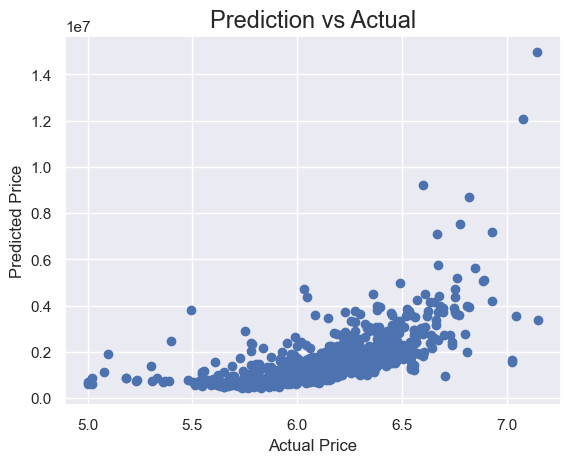

In [42]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Prediction vs Actual", fontsize=17)
plt.show()

### Final Model Selection

Elastic Net slightly outperformed the other models while maintaining good generalization between training and testing datasets.

Tree-based models exhibited signs of overfitting, with substantially higher training R² values but no improvement in test performance.

Given its strong performance and interpretability, **Elastic Net was selected as the final model.**

• Test Adjusted R²: **0.542**  
• Test MAE: **$474,111.60**

These results indicate that the model captures a substantial portion of price variation while maintaining reasonable prediction error.

Future improvements could include:

• additional location-based features  
• more granular spatial modeling  
• hyperparameter optimization

In [43]:
model_comparison.sort_values("MAE", ascending=True)

,Model Name,Train Adjusted R2,Test Adjusted R2,MAE
1,Elastic Net,0.599,0.542,474111.60
0,OLS,0.599,0.541,474825.12
2,Random Forest,0.737,0.541,482645.38
3,XGBoost,0.701,0.542,487822.11


### Save Final Model

In [44]:
import joblib
from sklearn.pipeline import Pipeline

In [45]:
# Train final model and fit on full dataset
final_model = ElasticNetCV(
    cv=5,
    max_iter=10000
)

final_model.fit(X, y)

# Save model
joblib.dump(final_model, MODELS_DIR / "home_price_model.joblib")

['C:\\Users\\jac67\\Documents\\Data and Analytics\\Python\\brooklyn-home-sales\\models\\home_price_model.joblib']